# Principal Component Analysis

This warm-up exercise will help you build an intuitive understanding of how **Principal Component Analysis** works.

## (1) Data Generation

We want a dataset with **100 observations** and **2 correlated features**.

👇 Run the cell below to generate your data  
💡 Notice the (high) correlation between the two features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a dataset with 100 observations and 2 correlated features.
seed = np.random.RandomState(42)
feature_1 = seed.normal(5, 1, 100)
feature_2 = .7 * feature_1 + seed.normal(0, .5, 100)
X = np.array([feature_1, feature_2]).T
X = pd.DataFrame(X)

X.corr().round(3)

,0,1
0,1.00,0.77
1,0.77,1.00


❓ Plot a scatter plot of your two features against each other.

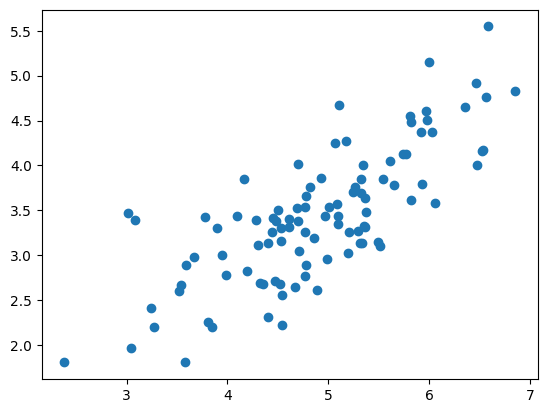

In [3]:
plt.scatter(feature_1, feature_2)

☝️ You can identify the **positive correlation** between the features.

Our observations are clustered along a single line, making it hard to distinguish the differences between them.

💡 PCA will help us find directions (also known as **"principal components"**) that eliminate this correlation.

## (2) Principal Components

👉 Import `PCA` from `sklearn` and create a model with `n_components=2`

❓ Fit it on your `X` and assign it to `pca`

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

Let's focus on three attributes of the trained `PCA` object:

* `pca.components_`: A set of eigenvectors indicating the directions in which variance is best explained; i.e. **directions of maximum variance** (normalized to unit length by convention).

* `pca.explained_variance_`:  
  $Var(\text{Principal Component})$, the variance explained by each principal component (given by the eigenvalues of the covariance matrix  
  $ \Sigma = \frac{1}{n - 1} X^T X $).

* `pca.explained_variance_ratio_`:  
  $ \frac{Var(\text{Principal Component})}{\text{Total Variance}}$, the proportion of total variance explained by each principal component.

In [5]:
# Vector coordinates of each principal component
pca.components_

array([[ 0.79286897,  0.60939216],
       [-0.60939216,  0.79286897]])

In [6]:
# Explained variance for each principal component
# Sorted in descending order of importance
pca.explained_variance_

array([1.2231014 , 0.15046893])

In [7]:
# Explained variance ratio for each principal component
# Sorted in descending order of importance

# Explained variance for each principal component
# divided by the total variance of the data
pca.explained_variance_ratio_

array([0.89045415, 0.10954585])

👇 Run the cell below to visualize your two principal components.

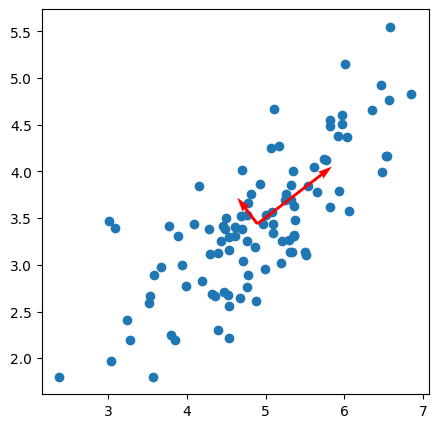

In [8]:
plt.figure(figsize=(5,5))

plt.scatter(X[0], X[1])

for (length, vector) in zip(pca.explained_variance_, pca.components_):
    v = vector * np.sqrt(length) # Square root of lengths to compare in the same "units"
    plt.quiver(*X.mean(axis=0), *v, units='xy', scale=1, color='r')

💡 The length of the vector is a measure of the standard deviation when the dataset is projected onto this axis!

💡 We can then use these directions (these "principal components") to "explain" most of the behavior of our observations — most of the differences between observations occur along these axes.

## (3) Apply PCA

Using these components, we can project each sample in our dataset onto the directions of maximum variance.

❓ ***Questions*** ❓

1. Use the `transform` method of the `pca` object on `X` and save the result to `X_transformed`.  
2. Plot the projected features in `X_transformed` against each other.  
3. Compute the correlation between the transformed features in `X_transformed`.

In [9]:
X_transformed = pca.transform(X)

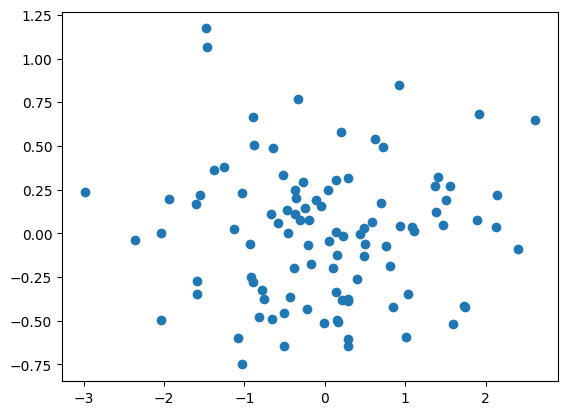

In [21]:
plt.scatter(X_transformed[:,0], X_transformed[:,1])

In [22]:
pd.DataFrame(X_transformed).corr().round(3)

,0,1
0,1.0,-0.0
1,-0.0,1.0


☝️ There is no correlation between your transformed features.  

This makes it easier to examine the behavior between observations, as they are no longer clustered along a single line.

🏁 **Don't forget to PUSH your notebook.**  

Complete the day's tasks and come back here if you have time 😉

## (Optional) With a little help from Scaling

Keep in mind that the **projections** obtained with `PCA` are simply the dot product of the original `X` matrix and the *transposed* components (i.e. the eigenvectors from `pca.components_`).

👉 Compute the projected values **manually** using the dot product:  
$X \cdot PC^T$

❓ Use `np.allclose` to check whether your `X_transformed` and the computed $X \cdot PC^T$ are **the same**.

In [25]:
PC = pca.components_
np.allclose(X_transformed, np.dot(X, PC.T))

False

Not equal 😱  

When `sklearn`'s `PCA` applies the transformation, it does so on a *centered* but *unscaled* `X`.

This means that `PCA().transform(X)` is actually equivalent to `np.dot(X - X.mean(axis=0), PC)`.

In [26]:
np.allclose(X_transformed, np.dot(X - X.mean(axis=0), PC.T))

True

Therefore, when using `PCA`, we recommend first scaling — more precisely, standardizing — your data so that it becomes centered.

This way, using `PCA.transform()` or computing the dot product with the principal components will be equivalent.